# Fine-tuning Results: No DP vs DP-SGD
Comparing accuracy and F1 score across rounds

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Load data ──────────────────────────────────────────────────────────────
nodp = pd.read_csv('/home/clara/Research2.0/fyp_fl_smart_home/hardware_exp/finetune_results_nodp.csv')
dp   = pd.read_csv('/home/clara/Research2.0/fyp_fl_smart_home/hardware_exp/finetune_results_dp.csv')

# Add round 0 (pretrained baseline before any fine-tuning)
baseline_acc = nodp['acc_before'].iloc[0]  # same for both (same pretrained model)

rounds_nodp = [0] + nodp['round'].tolist()
rounds_dp   = [0] + dp['round'].tolist()

acc_nodp = [baseline_acc] + nodp['acc_after'].tolist()
acc_dp   = [baseline_acc] + dp['acc_after'].tolist()
f1_nodp  = [None] + nodp['f1_after'].tolist()   # no F1 for baseline
f1_dp    = [None] + dp['f1_after'].tolist()

print('No-DP results:')
print(nodp[['round','acc_before','acc_after','f1_after','train_time_s','memory_mb']].to_string(index=False))
print()
print('DP results:')
print(dp[['round','acc_before','acc_after','f1_after','train_time_s','memory_mb']].to_string(index=False))

No-DP results:
 round  acc_before  acc_after  f1_after  train_time_s  memory_mb
     1      0.3968     0.9631    0.8815          78.0      541.1
     2      0.9631     0.9718    0.9046          75.3      541.8
     3      0.9718     0.9744    0.9153          75.2      542.0
     4      0.9744     0.9872    0.9699          75.2      542.2
     5      0.9872     0.9823    0.9627          75.2      540.7

DP results:
 round  acc_before  acc_after  f1_after  train_time_s  memory_mb
     1      0.3968     0.9184    0.6710         150.7      606.7
     2      0.9184     0.9331    0.6951         149.2      604.7
     3      0.9331     0.9364    0.7214         149.3      606.7
     4      0.9364     0.9425    0.7518         149.4      611.4
     5      0.9425     0.9455    0.7579         149.5      616.4


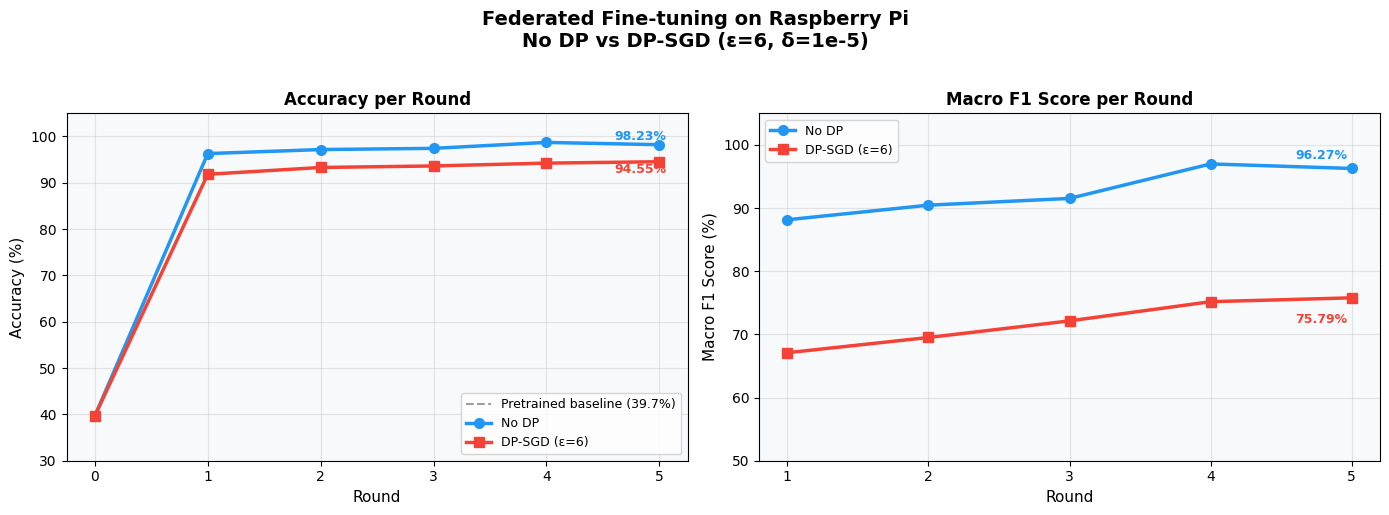

Saved: finetune_acc_f1_comparison.png


In [4]:
# ── Plot 1: Accuracy comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Federated Fine-tuning on Raspberry Pi\nNo DP vs DP-SGD (ε=6, δ=1e-5)',
             fontsize=14, fontweight='bold', y=1.02)

COLOR_NODP = '#2196F3'   # blue
COLOR_DP   = '#F44336'   # red
COLOR_BASE = '#9E9E9E'   # grey

# ── Subplot 1: Accuracy ────────────────────────────────────────────────────
ax1 = axes[0]
ax1.axhline(y=baseline_acc, color=COLOR_BASE, linestyle='--',
            linewidth=1.5, label=f'Pretrained baseline ({baseline_acc*100:.1f}%)')
ax1.plot(rounds_nodp, [a*100 for a in acc_nodp],
         color=COLOR_NODP, marker='o', linewidth=2.5, markersize=7, label='No DP')
ax1.plot(rounds_dp, [a*100 for a in acc_dp],
         color=COLOR_DP, marker='s', linewidth=2.5, markersize=7, label='DP-SGD (ε=6)')

# Annotate final values
ax1.annotate(f"{acc_nodp[-1]*100:.2f}%",
             xy=(rounds_nodp[-1], acc_nodp[-1]*100),
             xytext=(rounds_nodp[-1]-0.4, acc_nodp[-1]*100+1),
             fontsize=9, color=COLOR_NODP, fontweight='bold')
ax1.annotate(f"{acc_dp[-1]*100:.2f}%",
             xy=(rounds_dp[-1], acc_dp[-1]*100),
             xytext=(rounds_dp[-1]-0.4, acc_dp[-1]*100-2.5),
             fontsize=9, color=COLOR_DP, fontweight='bold')

ax1.set_xlabel('Round', fontsize=11)
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_title('Accuracy per Round', fontsize=12, fontweight='bold')
ax1.set_xticks(range(0, len(rounds_nodp)))
ax1.set_ylim(30, 105)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#f8f9fa')

# ── Subplot 2: F1 Score ────────────────────────────────────────────────────
ax2 = axes[1]
f1_rounds = list(range(1, len(nodp)+1))
ax2.plot(f1_rounds, [f*100 for f in nodp['f1_after']],
         color=COLOR_NODP, marker='o', linewidth=2.5, markersize=7, label='No DP')
ax2.plot(f1_rounds, [f*100 for f in dp['f1_after']],
         color=COLOR_DP, marker='s', linewidth=2.5, markersize=7, label='DP-SGD (ε=6)')

# Annotate final values
ax2.annotate(f"{nodp['f1_after'].iloc[-1]*100:.2f}%",
             xy=(f1_rounds[-1], nodp['f1_after'].iloc[-1]*100),
             xytext=(f1_rounds[-1]-0.4, nodp['f1_after'].iloc[-1]*100+1.5),
             fontsize=9, color=COLOR_NODP, fontweight='bold')
ax2.annotate(f"{dp['f1_after'].iloc[-1]*100:.2f}%",
             xy=(f1_rounds[-1], dp['f1_after'].iloc[-1]*100),
             xytext=(f1_rounds[-1]-0.4, dp['f1_after'].iloc[-1]*100-4),
             fontsize=9, color=COLOR_DP, fontweight='bold')

ax2.set_xlabel('Round', fontsize=11)
ax2.set_ylabel('Macro F1 Score (%)', fontsize=11)
ax2.set_title('Macro F1 Score per Round', fontsize=12, fontweight='bold')
ax2.set_xticks(f1_rounds)
ax2.set_ylim(50, 105)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('finetune_acc_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: finetune_acc_f1_comparison.png')

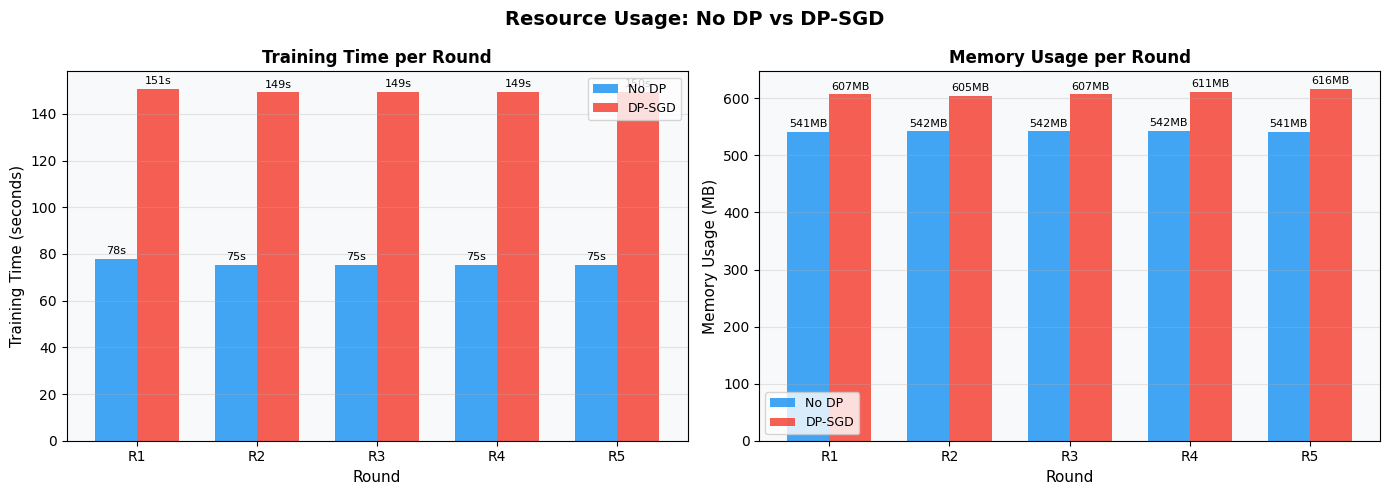

Saved: finetune_resource_comparison.png


In [5]:
# ── Plot 2: Resource comparison (training time & memory) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Resource Usage: No DP vs DP-SGD', fontsize=14, fontweight='bold')

rounds = nodp['round'].tolist()
x = np.arange(len(rounds))
width = 0.35

# ── Training time ──────────────────────────────────────────────────────────
ax3 = axes[0]
bars1 = ax3.bar(x - width/2, nodp['train_time_s'], width,
                color=COLOR_NODP, alpha=0.85, label='No DP')
bars2 = ax3.bar(x + width/2, dp['train_time_s'], width,
                color=COLOR_DP, alpha=0.85, label='DP-SGD')

ax3.bar_label(bars1, fmt='%.0fs', padding=2, fontsize=8)
ax3.bar_label(bars2, fmt='%.0fs', padding=2, fontsize=8)
ax3.set_xlabel('Round', fontsize=11)
ax3.set_ylabel('Training Time (seconds)', fontsize=11)
ax3.set_title('Training Time per Round', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f'R{r}' for r in rounds])
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_facecolor('#f8f9fa')

# ── Memory usage ───────────────────────────────────────────────────────────
ax4 = axes[1]
bars3 = ax4.bar(x - width/2, nodp['memory_mb'], width,
                color=COLOR_NODP, alpha=0.85, label='No DP')
bars4 = ax4.bar(x + width/2, dp['memory_mb'], width,
                color=COLOR_DP, alpha=0.85, label='DP-SGD')

ax4.bar_label(bars3, fmt='%.0fMB', padding=2, fontsize=8)
ax4.bar_label(bars4, fmt='%.0fMB', padding=2, fontsize=8)
ax4.set_xlabel('Round', fontsize=11)
ax4.set_ylabel('Memory Usage (MB)', fontsize=11)
ax4.set_title('Memory Usage per Round', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels([f'R{r}' for r in rounds])
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('finetune_resource_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: finetune_resource_comparison.png')

In [6]:
# ── Summary table ──────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': [
        'Pretrained (before fine-tune)',
        'After fine-tune (No DP) - Round 5',
        'After fine-tune (DP-SGD ε=6) - Round 5',
        'Accuracy drop due to DP',
        'Avg training time - No DP',
        'Avg training time - DP-SGD',
        'Avg memory - No DP',
        'Avg memory - DP-SGD',
    ],
    'Value': [
        f"{baseline_acc*100:.2f}%",
        f"{nodp['acc_after'].iloc[-1]*100:.2f}%  (F1: {nodp['f1_after'].iloc[-1]*100:.2f}%)",
        f"{dp['acc_after'].iloc[-1]*100:.2f}%  (F1: {dp['f1_after'].iloc[-1]*100:.2f}%)",
        f"{(nodp['acc_after'].iloc[-1] - dp['acc_after'].iloc[-1])*100:.2f}%",
        f"{nodp['train_time_s'].mean():.1f}s",
        f"{dp['train_time_s'].mean():.1f}s  ({dp['train_time_s'].mean()/nodp['train_time_s'].mean():.1f}x slower)",
        f"{nodp['memory_mb'].mean():.0f} MB",
        f"{dp['memory_mb'].mean():.0f} MB  (+{dp['memory_mb'].mean()-nodp['memory_mb'].mean():.0f} MB)",
    ]
})

print('='*65)
print('SUMMARY: Privacy-Utility-Resource Tradeoff')
print('='*65)
print(summary.to_string(index=False))
print('='*65)

SUMMARY: Privacy-Utility-Resource Tradeoff
                                Metric                 Value
         Pretrained (before fine-tune)                39.68%
     After fine-tune (No DP) - Round 5  98.23%  (F1: 96.27%)
After fine-tune (DP-SGD ε=6) - Round 5  94.55%  (F1: 75.79%)
               Accuracy drop due to DP                 3.68%
             Avg training time - No DP                 75.8s
            Avg training time - DP-SGD 149.6s  (2.0x slower)
                    Avg memory - No DP                542 MB
                   Avg memory - DP-SGD      609 MB  (+68 MB)
